# EDA

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import textwrap

import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data
from src.utils.config import FEATURE_COLS, FEATURE_DESCRIPTIONS, TARGET_COL

sns.set_theme(style="whitegrid")

In [3]:
df = load_raw_data()
df.shape

(126, 7)

In [4]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


What each question asks:
- X1: my order was delivered on time
- X2: contents of my order was as I expected
- X3: I ordered everything I wanted to order
- X4: I paid a good price for my order
- X5: I am satisfied with my courier
- X6: the app makes ordering easy for me

## Data quality check

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [6]:
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Y     0
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(16)

In [9]:
df[FEATURE_COLS + [TARGET_COL]].nunique()

X1    4
X2    5
X3    5
X4    5
X5    5
X6    5
Y     2
dtype: int64

No missing values or out-of-range values. There are 16 duplicate rows (identical across X1-X6 and Y). With only 126 rows on a 1-5 scale, this is possible for different respondents. X1 also only uses 4 of its 5 possible values in this dataset.

Skipping outlier detection since values are bounded 1-5, so nothing counts as an outlier.

## Target

In [10]:
df[TARGET_COL].value_counts()

Y
1    69
0    57
Name: count, dtype: int64

In [11]:
df[TARGET_COL].value_counts(normalize=True).round(2)

Y
1    0.55
0    0.45
Name: proportion, dtype: float64

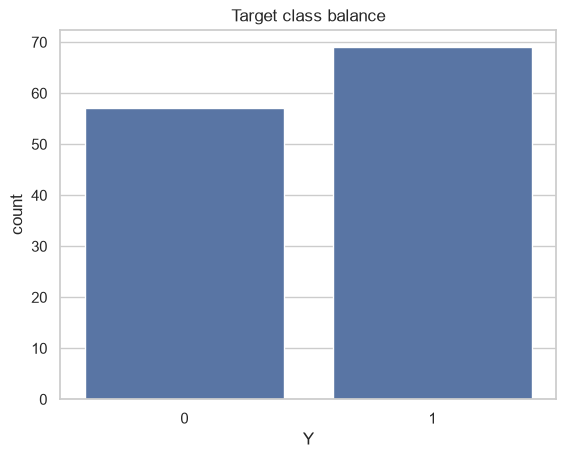

In [12]:
sns.countplot(x=TARGET_COL, data=df)
plt.title("Target class balance")
plt.show()

About 55% of customers are happy (Y=1), 45% are unhappy (Y=0) based on the percentages above. A model that always guessed the majority class would only hit about 55% accuracy, so accuracy is a meaningful metric since the classes are not heavily imbalanced. Any real model needs to beat that number.

## Feature distributions

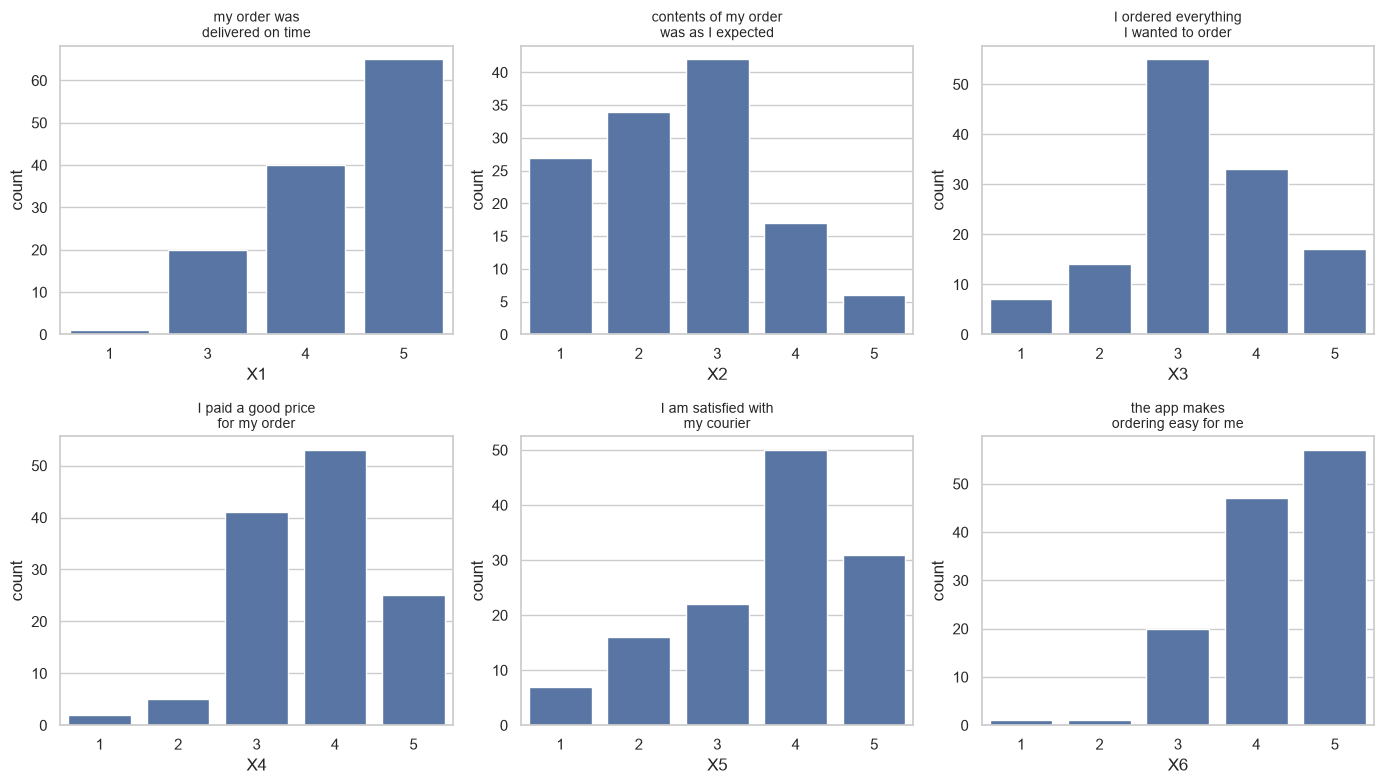

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.countplot(x=col, data=df, ax=ax, order=sorted(df[col].unique()))
    ax.set_title(textwrap.fill(FEATURE_DESCRIPTIONS[col], width=20), fontsize=10)
fig.tight_layout()
plt.show()

## Features vs. target

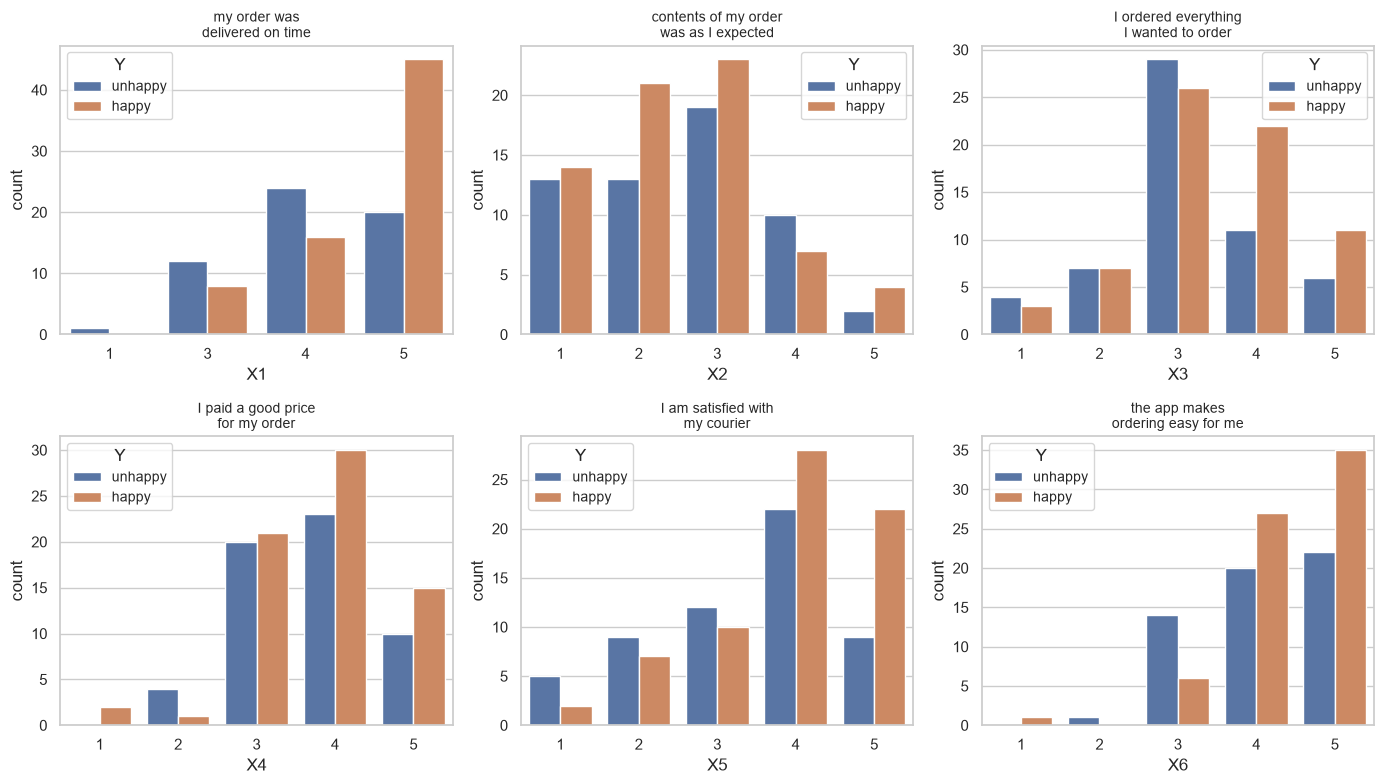

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.countplot(x=col, hue=TARGET_COL, data=df, ax=ax, order=sorted(df[col].unique()))
    ax.set_title(textwrap.fill(FEATURE_DESCRIPTIONS[col], width=20), fontsize=10)
    ax.legend(title="Y", labels=["unhappy", "happy"], fontsize="small")
fig.tight_layout()
plt.show()

In [15]:
df.groupby(TARGET_COL)[FEATURE_COLS].mean().round(2)

,X1,X2,X3,X4,X5,X6
Y,,,,,,
0,4.09,2.56,3.14,3.68,3.37,4.11
1,4.54,2.51,3.45,3.80,3.88,4.38


Using mean for consistency with the correlation/regression work later.

## Correlations

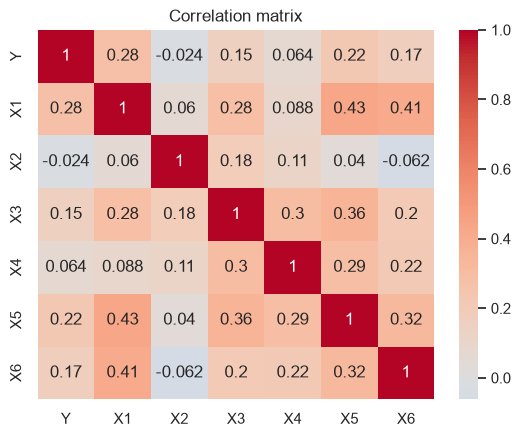

In [16]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

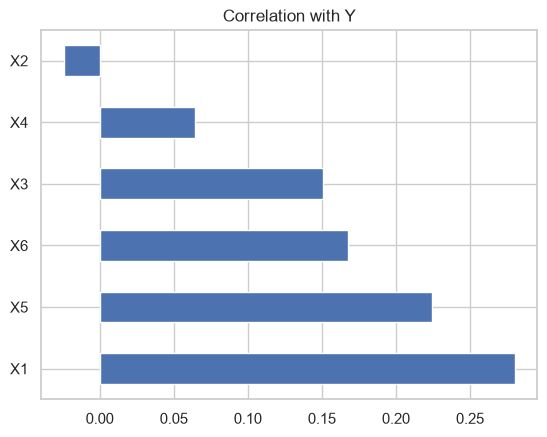

In [17]:
corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).plot(kind="barh")
plt.title("Correlation with Y")
plt.show()

X1 and X5 stand out, X2 is close to zero. This matches the split-by-target plots above. Keeping an eye on X2 (and X4, similarly weak).

## Summary

- No missing values or out-of-range values. There are 16 duplicate rows, though these may just reflect identical answers from different respondents rather than a data error.
- Classes are roughly 55/45 (happy/unhappy). Baseline (always guess majority) is about 55% accuracy.
- X1 and X5 are the strongest predictors of Y; X2 and X4 are the weakest.
- X1, X5, and X6 are moderately correlated with each other.